# Global Happiness Report Analysis

In this notebook I am analyzing the World Happiness Report (2015) dataset to understand what factors contribute most to a country's happiness score. I will clean the data, look at some basic statistics, and then visualize the relationship between happiness score and variables like GDP per capita, social support (family), and life expectancy (health).

## 1. Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

## 2. Loading the Dataset

In [2]:
df = pd.read_csv('2015.csv')
df.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


## 3. Basic Exploration

In [3]:
df.shape

(158, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    str    
 1   Region                         158 non-null    str    
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), str(2)
memory usage: 14.9 KB


In [5]:
df.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


Checking if there are any missing values in the dataset.

In [6]:
df.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

There are no missing values, so the dataset is already clean and I don't need to drop or fill anything.

## 4. Data Cleaning

In [7]:
df.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual'],
      dtype='str')

In [8]:
df.rename(columns={
    'Economy (GDP per Capita)': 'GDP_per_Capita',
    'Health (Life Expectancy)': 'Life_Expectancy',
    'Trust (Government Corruption)': 'Trust_Government',
    'Happiness Score': 'Happiness_Score',
    'Happiness Rank': 'Happiness_Rank'
}, inplace=True)
df.columns

Index(['Country', 'Region', 'Happiness_Rank', 'Happiness_Score',
       'Standard Error', 'GDP_per_Capita', 'Family', 'Life_Expectancy',
       'Freedom', 'Trust_Government', 'Generosity', 'Dystopia Residual'],
      dtype='str')

In [9]:
df.duplicated().sum()

np.int64(0)

## 5. Categorizing Countries by Happiness Level

I wanted to group each country into a happiness category based on its score, so I used a `match` statement to assign a label depending on which range the score falls into.

In [10]:
def happiness_level(score):
    match score:
        case s if s >= 7:
            return 'Very Happy'
        case s if s >= 6:
            return 'Happy'
        case s if s >= 5:
            return 'Moderate'
        case s if s >= 4:
            return 'Low'
        case _:
            return 'Very Low'

df['Happiness_Level'] = df['Happiness_Score'].apply(happiness_level)
df[['Country', 'Happiness_Score', 'Happiness_Level']].head(10)

,Country,Happiness_Score,Happiness_Level
0,Switzerland,7.587,Very Happy
1,Iceland,7.561,Very Happy
2,Denmark,7.527,Very Happy
3,Norway,7.522,Very Happy
4,Canada,7.427,Very Happy
5,Finland,7.406,Very Happy
6,Netherlands,7.378,Very Happy
7,Sweden,7.364,Very Happy
8,New Zealand,7.286,Very Happy
9,Australia,7.284,Very Happy


In [11]:
df['Happiness_Level'].value_counts()

Happiness_Level
Moderate      49
Low           44
Happy         29
Very Low      21
Very Happy    15
Name: count, dtype: int64

## 6. Top and Bottom Countries

In [12]:
df[['Country', 'Region', 'Happiness_Score']].sort_values('Happiness_Score', ascending=False).head(10)

,Country,Region,Happiness_Score
0,Switzerland,Western Europe,7.587
1,Iceland,Western Europe,7.561
2,Denmark,Western Europe,7.527
3,Norway,Western Europe,7.522
4,Canada,North America,7.427
5,Finland,Western Europe,7.406
6,Netherlands,Western Europe,7.378
7,Sweden,Western Europe,7.364
8,New Zealand,Australia and New Zealand,7.286
9,Australia,Australia and New Zealand,7.284


In [13]:
df[['Country', 'Region', 'Happiness_Score']].sort_values('Happiness_Score', ascending=True).head(10)

,Country,Region,Happiness_Score
157,Togo,Sub-Saharan Africa,2.839
156,Burundi,Sub-Saharan Africa,2.905
155,Syria,Middle East and Northern Africa,3.006
154,Benin,Sub-Saharan Africa,3.340
153,Rwanda,Sub-Saharan Africa,3.465
152,Afghanistan,Southern Asia,3.575
151,Burkina Faso,Sub-Saharan Africa,3.587
150,Ivory Coast,Sub-Saharan Africa,3.655
149,Guinea,Sub-Saharan Africa,3.656
148,Chad,Sub-Saharan Africa,3.667


## 7. Average Happiness Score by Region

In [14]:
region_avg = df.groupby('Region')['Happiness_Score'].mean().sort_values(ascending=False)
region_avg

Region
Australia and New Zealand          7.285000
North America                      7.273000
Western Europe                     6.689619
Latin America and Caribbean        6.144682
Eastern Asia                       5.626167
Middle East and Northern Africa    5.406900
Central and Eastern Europe         5.332931
Southeastern Asia                  5.317444
Southern Asia                      4.580857
Sub-Saharan Africa                 4.202800
Name: Happiness_Score, dtype: float64

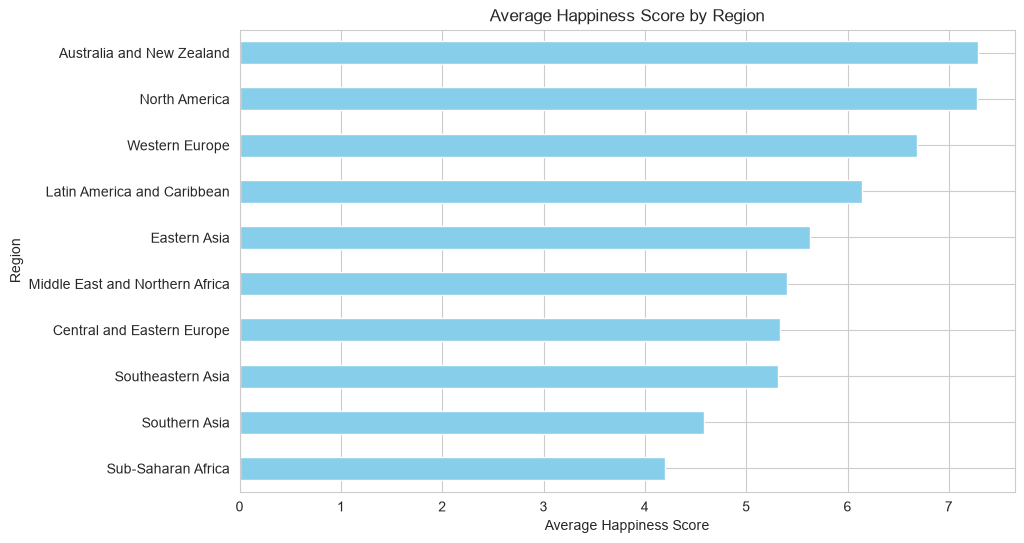

In [15]:
plt.figure(figsize=(10,6))
region_avg.plot(kind='barh', color='skyblue')
plt.xlabel('Average Happiness Score')
plt.ylabel('Region')
plt.title('Average Happiness Score by Region')
plt.gca().invert_yaxis()
plt.show()

## 8. Correlation Between Happiness and Other Factors

In [16]:
cols = ['Happiness_Score', 'GDP_per_Capita', 'Family', 'Life_Expectancy', 'Freedom', 'Trust_Government', 'Generosity']
corr = df[cols].corr()
corr

,Happiness_Score,GDP_per_Capita,Family,Life_Expectancy,Freedom,Trust_Government,Generosity
Happiness_Score,1.000000,0.780966,0.740605,0.724200,0.568211,0.395199,0.180319
GDP_per_Capita,0.780966,1.000000,0.645299,0.816478,0.370300,0.307885,-0.010465
Family,0.740605,0.645299,1.000000,0.531104,0.441518,0.205605,0.087513
Life_Expectancy,0.724200,0.816478,0.531104,1.000000,0.360477,0.248335,0.108335
Freedom,0.568211,0.370300,0.441518,0.360477,1.000000,0.493524,0.373916
Trust_Government,0.395199,0.307885,0.205605,0.248335,0.493524,1.000000,0.276123
Generosity,0.180319,-0.010465,0.087513,0.108335,0.373916,0.276123,1.000000


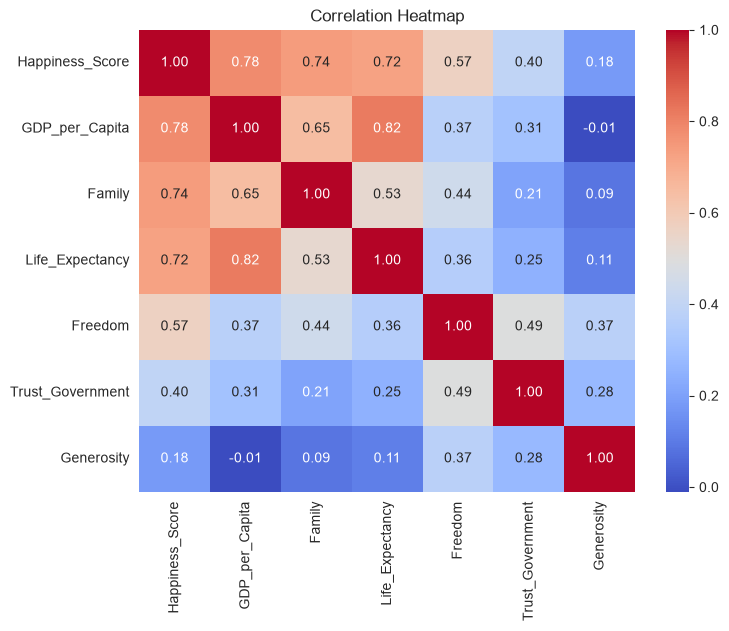

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

From the heatmap, it looks like GDP per capita, Family (social support), and Life Expectancy have the strongest positive correlation with the happiness score.

## 9. Happiness Score vs GDP per Capita

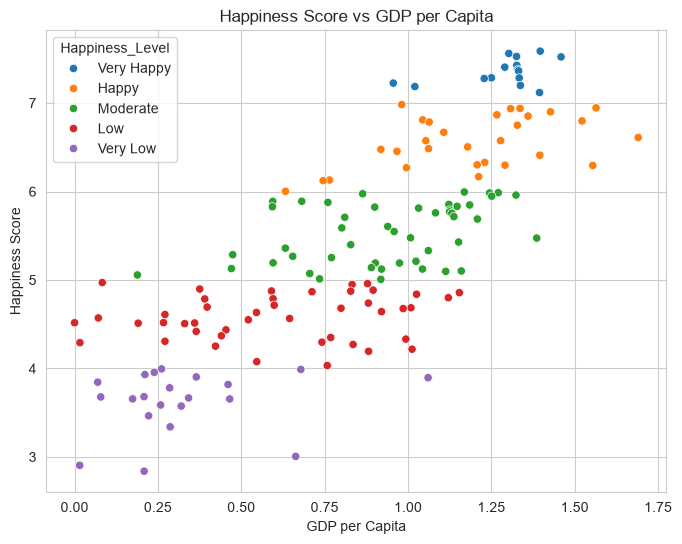

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='GDP_per_Capita', y='Happiness_Score', hue='Happiness_Level')
plt.title('Happiness Score vs GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.show()

## 10. Happiness Score vs Social Support (Family)

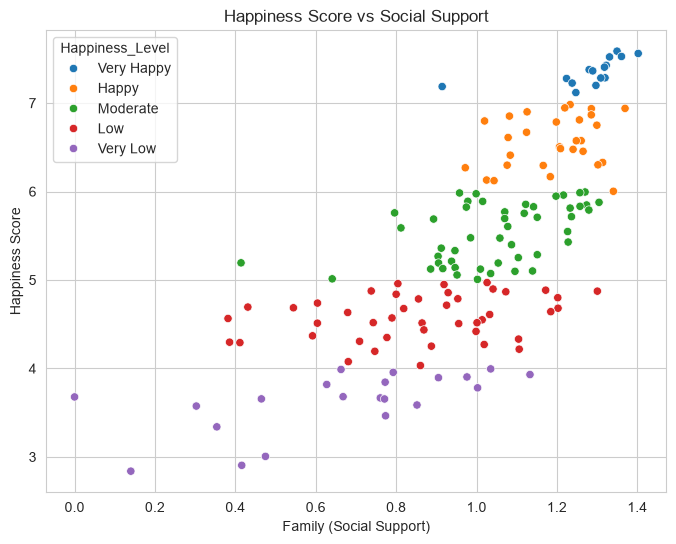

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Family', y='Happiness_Score', hue='Happiness_Level')
plt.title('Happiness Score vs Social Support')
plt.xlabel('Family (Social Support)')
plt.ylabel('Happiness Score')
plt.show()

## 11. Happiness Score vs Life Expectancy

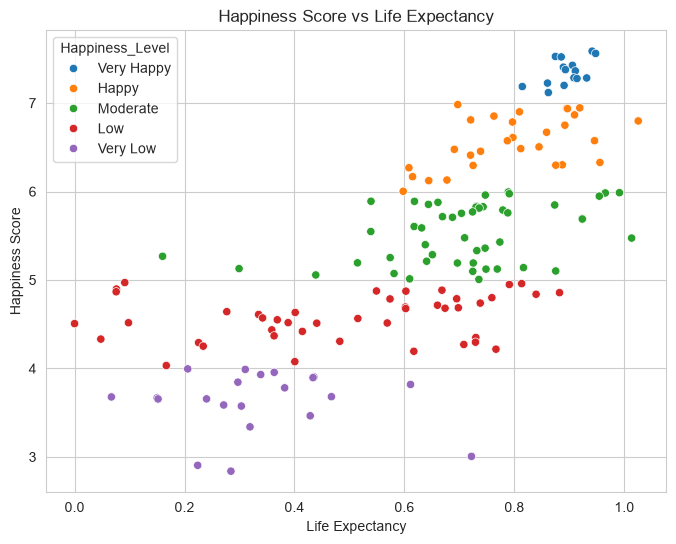

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Life_Expectancy', y='Happiness_Score', hue='Happiness_Level')
plt.title('Happiness Score vs Life Expectancy')
plt.xlabel('Life Expectancy')
plt.ylabel('Happiness Score')
plt.show()

## 12. Pairplot of the Main Factors

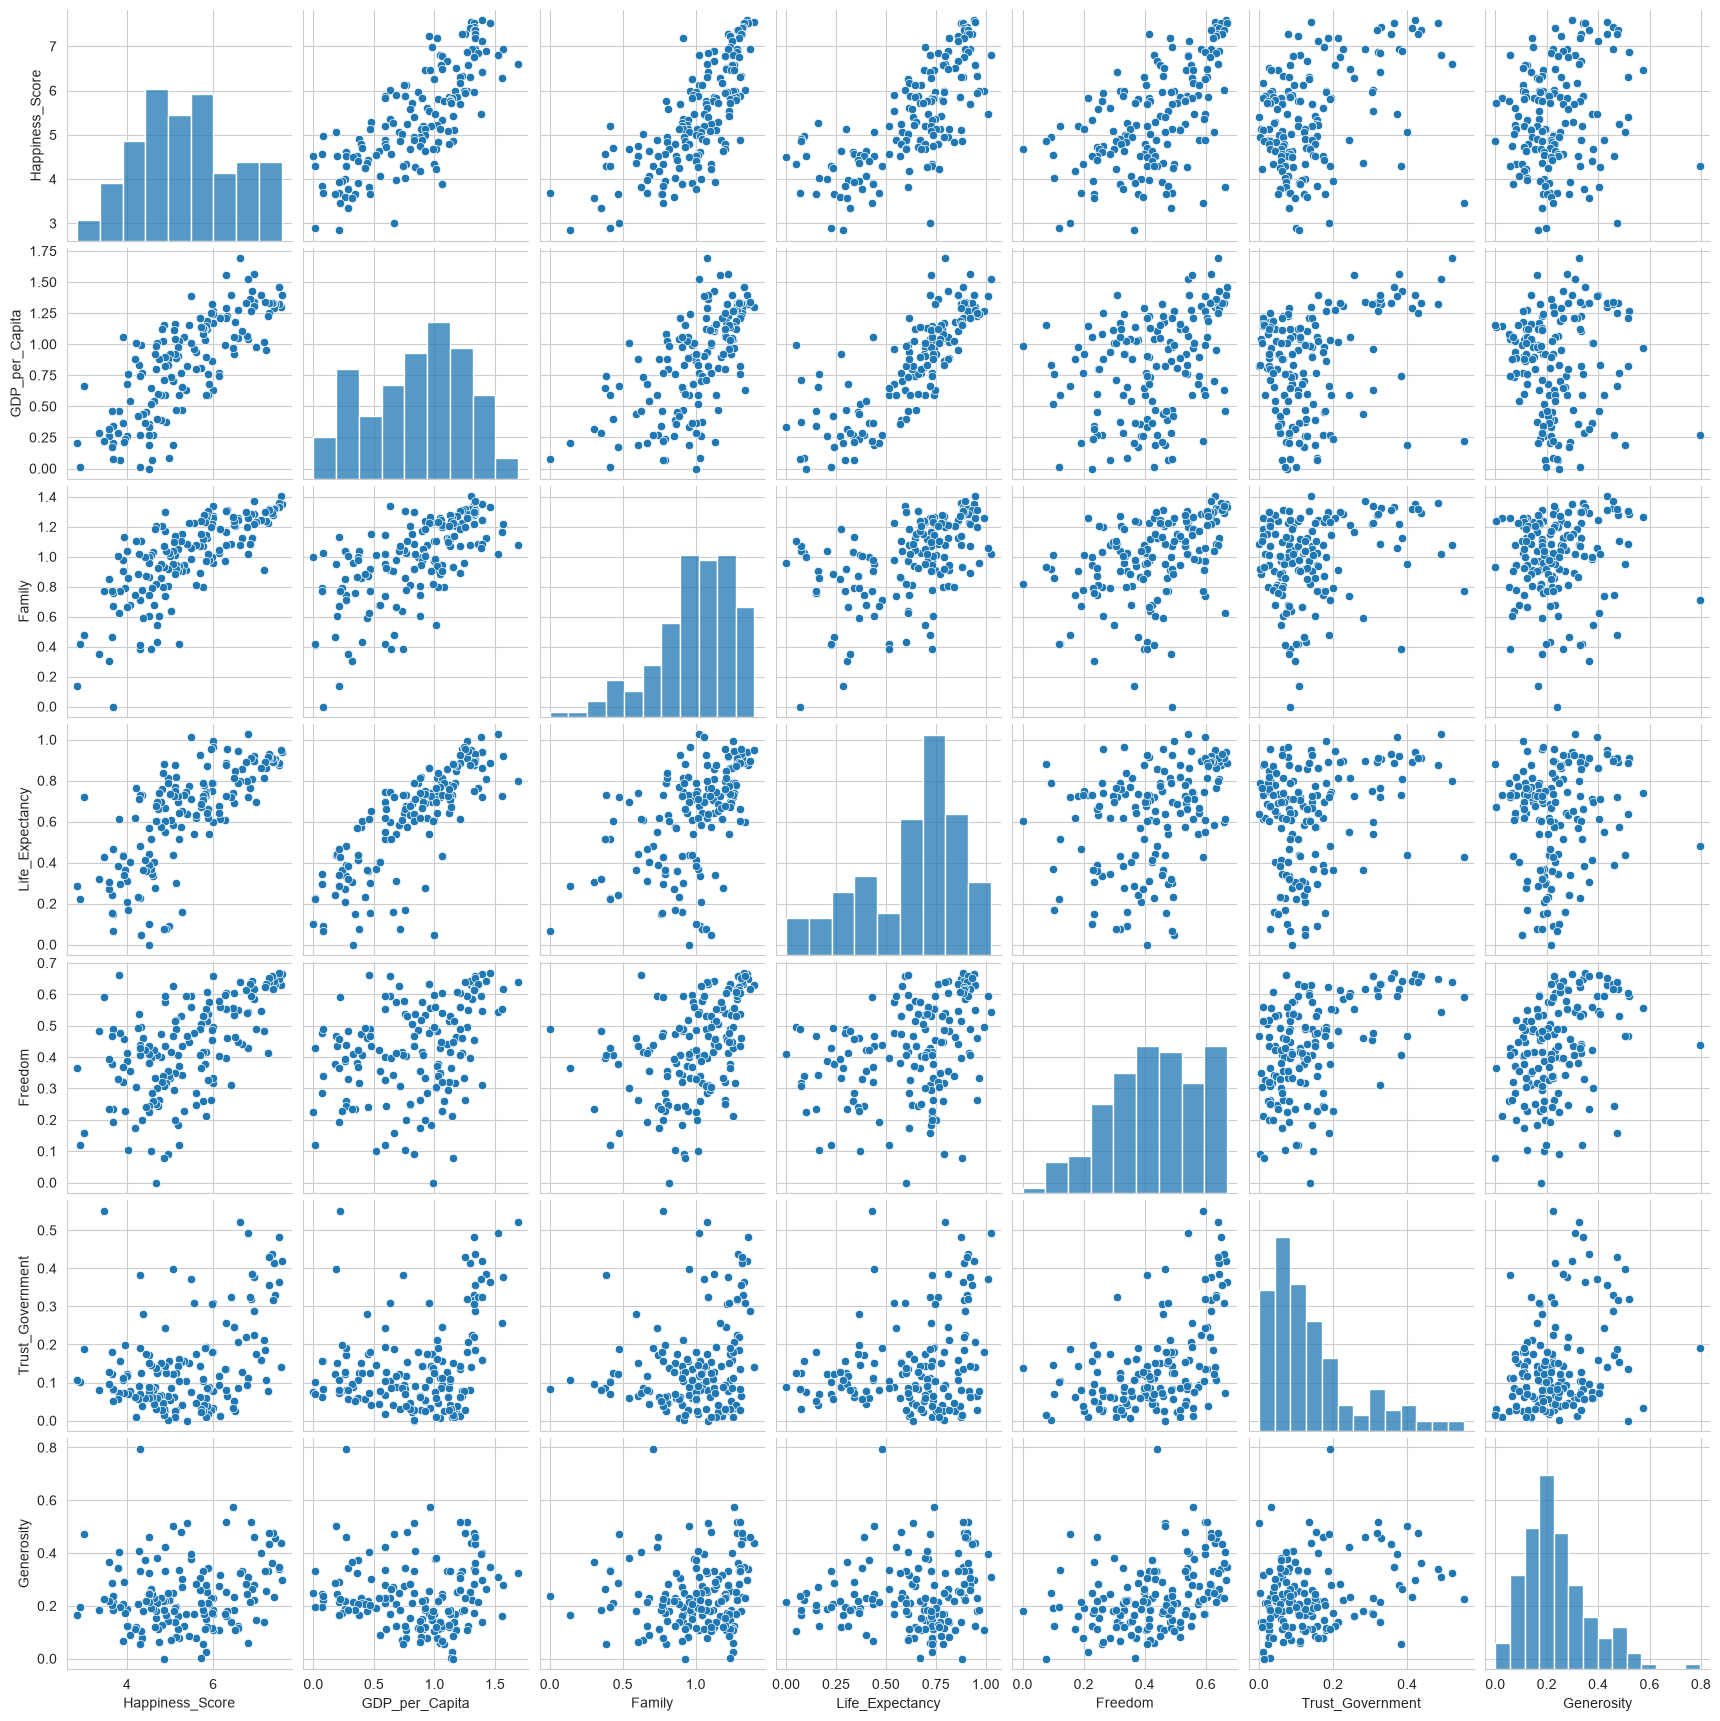

In [21]:
sns.pairplot(df[cols])
plt.show()

## 13. Conclusion

Based on this analysis, GDP per capita, social support (family), and life expectancy all show a fairly strong positive correlation with a country's happiness score. Countries in Western Europe, North America, and Australia/New Zealand tend to have the highest average happiness scores, while countries in Sub-Saharan Africa tend to have the lowest. This suggests that economic strength, strong social relationships, and good health are all closely linked to how happy people report being in their country.